## Mapping Surface Runoff Susceptibility in Nisqually River Watershed, Washington Under Changing Climate Conditions

#### Introduction

Water's movement around the world, from the atmosphere through the landscape, is a complex and interesting journey. Water is powerful and fundamental to many processes on Earth, yet it can also be elusive… hard to model and difficult to predict. It also drives one of the most common natural disasters worldwide: flooding. 

Surface runoff, [defined as water that flows across the land surface](https://www.usgs.gov/water-science-school/science/surface-runoff-and-water-cycle), is a major driver of flooding and how it develops across the landscape. Excessive surface runoff leads not only to flooding that impacts public safety and infrastructure, but also to:

- Increased soil erosion and landslides  
- Reduced groundwater and aquifer recharge  
- Degraded water quality from pollutant transport  
- Increased turbidity and drinking water treatment costs  
- Flashier streams (water levels rising and falling rapidly during storm events) 
- Stream channel instability  
- Impacts on habitats and species, such as salmon  

Climate change is projected to increase wet-season precipitation and storm intensity in regions like the Puget Sound. This raises an important question: where is surface runoff susceptibility highest under current conditions, and how might those patterns shift in the future?

We don’t always have a strong understanding of where surface runoff is most susceptible, and flood response is often reactive rather than proactive. This can increase public safety risks and lead to significant financial costs when impacts are addressed after the fact. To support more resilient infrastructure and communities, and to make more effective use of limited resources, it is increasingly important to better understand surface runoff and how it might shift with a changing climate.

This project aims to map surface runoff susceptibility within the Nisqually River watershed and explore how these patterns may change under future climate change scenarios.

#### Background & Study Area

The Nisqually Watershed in Washington, USA, was selected for this study due to its wide range of characteristics that influence surface runoff, making it a good candidate to explore surface runoff susceptibility spatially. The Nisqually River headwaters run from Mount Rainier, [an active volcano around 500,000 years old in its current form](https://www.usgs.gov/volcanoes/mount-rainier/science/geology-and-history-summary-mount-rainier), and originates from the Nisqually Glacier. It flows approximately 70 miles to Puget Sound, an inlet estuary of the Pacific Ocean. The Nisqually runs through a large elevation range, Mount Rainier at over 4,000 ft to sea level at the mouth of the river. The watershed contains a variety of land covers, including mountain, forest, agriculture, and urban areas. This diversity of landscape makes it an ideal study area for how surface runoff varies spatially. 

There are many methods and models that have been created to map surface runoff susceptibility. One approach, presented in a [2016 Journal of Hydrology paper by Lagadec et al.](https://www.sciencedirect.com/science/article/abs/pii/S002216941630316X), maps surface runoff susceptibility through the Indicator of Intense Pluvial Runoff (IRIP) method by combining landscape factors like terrain, soils, and land use, instead of relying on fully simulated and complex hydrologic models. Terrain is used as it controls the movement of water across the landscape, soil type controls how quickly water infiltrates, and land cover, such as impervious surface, changes runoff behavior.

Simpler approaches, such as the IRIP method, are important to hydrologic modeling, as many other types of models can be computationally expensive, require intensive data calibration, lack access to quality input data, and have limits on model transferability across regions. More complex and simulated models are not always feasible approaches to be used broadly, especially for a screening-level analysis across organizations.

The Interstate Commission on the Potomac River Basin (ICPRB) developed an [interactive surface runoff map](https://www.potomacriver.org/news/new-interactive-map-to-identify-areas-vulnerable-to-stormwater-runoff/) and “susceptibility index” in February 2026 based on landscape characteristics. Their inputs included total watershed area, percent of watershed with underlying karst geology, average annual precipitation, soil characteristics, physiographic province, and average watershed slope. Similarly, they identified the need for mapping surface runoff susceptibility as a tool for decision-makers in planning, resource allocation, mitigation, and risk management. 

There are trade-offs to be considered in a susceptibility-focused spatial model versus a fully simulated model. Full similuated models can have higher accuracy, finer resolution, and more physical realism (if done properly) to model flow volumes, flow timing, etc. However, these models are often impractical at the large-scale or screening-level analysis needed for planning and decision-making, as they require large, detailed datasets and calibration with observed data, which may not always be available. 

This project builds off these ideas and approaches by using surface runoff landscape characteristics, including soils, topography, and land cover, and inputting them into a fuzzy logic model with average wet-season precipitation and one day max rainfall to create a surface runoff susceptibility map. It also explores how that might change under different climate scenarios, if at all. 

In [ ]:
# Import packages for working with files and folders
import os
import pathlib
from pathlib import Path
from glob import glob
import zipfile

# Import package for working with geospatial data
import geopandas as gpd

# Import package for working with tabular data
import pandas as pd

# Import libaray for plotting
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm

# Import library for scientific computation
import numpy as np

# Import library for making interactive plots with vector/tabular data
import hvplot.pandas 

# Import library for making interactive plot
import holoviews as hv

# Access NASA earth data (topography)
import earthaccess

# Import libraries for working with raster data
import rioxarray as rxr
import xarray as xr
import xrspatial

# Import library for merging raster data
from rioxarray.merge import merge_arrays

# Import for bilinear resampling during reprojection
from rasterio.enums import Resampling

# Read elevation raster and flow accumulation
from pysheds.grid import Grid

In [ ]:
# Create base project directory
project_dir = os.path.join(
    pathlib.Path.home(),
    "Documents",
    "education",
    "earth-data-analytics",
    "spring-2026-data",
    "surface-runoff-susceptibility-model"
)

# Define all directories in one dictionary
dirs = {
    "project": project_dir,
    "wbd": os.path.join(project_dir, "watershed-boundary-dataset"),
    "topography": os.path.join(project_dir, "topography"),
    "soils": os.path.join(project_dir, "soils"),
    "climate": os.path.join(project_dir, "climate"),
    "impervious": os.path.join(project_dir, "nlcd-impervious"),
    "inputs": os.path.join(project_dir, "final_inputs_5070"), 
}

# Create all directories
for path in dirs.values():
    os.makedirs(path, exist_ok=True)

# Assign individual dir variables
wbd_dir = dirs["wbd"]
topography_dir = dirs["topography"]
soils_dir = dirs["soils"]
climate_dir = dirs["climate"]
impervious_dir = dirs["impervious"]

# Check one of them
print(wbd_dir)
print(os.path.exists(wbd_dir))

In [ ]:
# Intialize path to DEM raster for pysheds use later
dem_5070_path = os.path.join(topography_dir, "nisqually_dem_5070.tif")

# Conditionally read the DEM raster if it exists, otherwise raise an error
if not os.path.exists(dem_5070_path):
    raise FileNotFoundError(f"DEM not found: {dem_5070_path}")

# Read the DEM raster using pysheds to create a grid object for hydrological analysis
grid = Grid.from_raster(dem_5070_path)
print("Grid ready")

#### Download Study Area Boundary - Nisqually River Watershed

In [ ]:
# Path to the downloaded zip file
zip_path = os.path.join(wbd_dir, "WBD_17_HU2_GPKG.zip")

# Extracted directory path
extract_dir = os.path.join(wbd_dir, "extracted")
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Path to GeoPackage (after unzip)
wbd_gpkg_path = os.path.join(extract_dir, "WBD_17_HU2_GPKG.gpkg")

# Read HUC8 layer
wbd_gdf = gpd.read_file(wbd_gpkg_path, layer="WBDHU8")

# Check the first few rows
print(wbd_gdf.head())

In [ ]:
# Check the columns
print(wbd_gdf.columns)

In [ ]:
# Check the geometry type
wbd_gdf.head()

In [ ]:
# Check for the Nisqually watershed
wbd_gdf[wbd_gdf["name"].str.contains("Nisqually", case=False)]

In [8]:
# Subset to just the Nisqually watershed
nisqually_gdf = wbd_gdf[wbd_gdf["huc8"] == "17110015"]

In [ ]:
# Check the name of the watershed
print(nisqually_gdf["name"])

In [ ]:
# Plot to see that it worked
nisqually_gdf.plot()

In [124]:
# Plot the results with web tile images
nisqually_gdf_plot = nisqually_gdf.hvplot(
    geo=True, tiles='EsriImagery',
    fill_color=None, line_color='white',
    title='Nisqually Watershed (HUC8 - 17110015) Washington, USA',
    frame_width=500,
    xlabel="Longitude",
    ylabel="Latitude")

# Display the plot with esri imagery
nisqually_gdf_plot

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

#### Figure 1: This map shows the watershed boundary of the Nisqually watershed in western Washington. Mount Rainier is visible in white at the headwaters, and the river flows through a variety of land cover types before reaching the Puget Sound. The diversity of terrain and land cover within the watershed makes it a useful study area for understanding spatial variation in surface runoff.

#### Data Sources

To capture the key landscape characteristics that drive surface runoff, the following datasets were used:

- **Topography** – NASA Shuttle Radar Topography Mission (SRTM, ~30 m resolution)  
  - Elevation  
  - Slope (derived, representing runoff potential)  
  - Flow accumulation (derived, representing areas of concentrated flow)  

- **Soils** – NRCS gSSURGO (gridded Soil Survey Geographic Database)  
  - Hydrologic Soil Group (A–D), used to represent soil drainage and infiltration capacity  

- **Land cover** – USGS National Land Cover Database (NLCD, 30 m resolution)  
  - Impervious surface percentage, representing developed surfaces and their influence on runoff

- **Climate data** – MACAv2 daily downscaled climate dataset  
  - Mean wet-season precipitation (Dec–Feb), representing overall precipitation conditions (historical and future)  
  - Rx1day (maximum 1-day precipitation), representing extreme rainfall intensity  

#### Methods

The data were processed to create input raster layers for a fuzzy logic model used to map surface runoff susceptibility on a scale from 0–1. 

The Digital Elevation Model (DEM) was used to derive slope and flow accumulation using the `pysheds` Python library. [Check it out!](https://github.com/pysheds/pysheds) These terrain variables help represent how water moves across the landscape.

Soil runoff potential was derived from hydrologic soil groups, which were rasterized and assigned scores from 0–1 based on relative infiltration capacity. The impervious surface layer was also processed and clipped to the study area extent to represent land surface characteristics that influence runoff.

From the MACA climate dataset, mean wet-season precipitation (December–February) and mean Rx1day (maximum 1-day precipitation) were calculated. Rx1day was used as a proxy for storm intensity. For both climate variables, historical (1975–2005) and mid-century future (2041–2070) scenarios were analyzed. The CCSM4 model was selected as it is closest to the mean projection across climate models in the region. The mid-century future period was selected to balance capturing projected climate change impacts while remaining relevant for near- to medium-term planning and decision-making.


All datasets were then harmonized to a common grid (EPSG:5070) to allow for consistent spatial analysis and to perserve area calculations which are important in hydrologic modeling.

### SRTM NASA Digital Elevation Model (30-m resolution)

In [12]:
# Set up Earth Access
earthaccess.login()

In [ ]:
# Search for SRTM data
datasets = earthaccess.search_datasets(keyword = "SRTM DEM")
for dataset in datasets:
    print(dataset['umm']['ShortName'], dataset['umm']['EntryTitle'])

In [14]:
# File pattern for data
nisqually_gdf_srtm_pattern = os.path.join(topography_dir, '*.hgt.zip')

# Study area for topo data
nisqually_gdf_elev_bounds = tuple(nisqually_gdf.total_bounds)

# Add buffer
buffer = 0.025
nisqually_xmin, nisqually_ymin, nisqually_xmax, nisqually_ymax = nisqually_gdf_elev_bounds
nisqually_elev_bounds_buffer = (nisqually_xmin - buffer,
                                 nisqually_ymin - buffer,
                                 nisqually_xmax + buffer,
                                 nisqually_ymax + buffer)

# Look at the results
srtm_files = glob(nisqually_gdf_srtm_pattern)

if not srtm_files:

    # Search for data
    nisqually_gdf_srtm_search = earthaccess.search_data(
        short_name = 'SRTMGL3',
        bounding_box = nisqually_elev_bounds_buffer
    )

    # Download data
    nisqually_gdf_srtm_results = earthaccess.download(
        nisqually_gdf_srtm_search,
        topography_dir
    )

# Add text if files already downloaded
else:
    print("SRTM files already downloaded")
    nisqually_gdf_srtm_results = srtm_files

SRTM files already downloaded


In [ ]:
# Check it out
nisqually_gdf_srtm_results

In [ ]:
# Create list to hold cropped SRTM tiles
nisqually_gdf_srtm_da_list = []
for srtm_path in glob(nisqually_gdf_srtm_pattern):
    tile_da = rxr.open_rasterio(srtm_path, mask_and_scale = True).squeeze()
    srtm_cropped_da = tile_da.rio.clip_box(*nisqually_elev_bounds_buffer)
    nisqually_gdf_srtm_da_list.append(srtm_cropped_da)

# Merge 
nisqually_srtm_da = merge_arrays(nisqually_gdf_srtm_da_list)

In [ ]:
# Save the merged raster to a new file to work with data issues
# Create a copy of the data array to modify for saving
nisqually_save_da = nisqually_srtm_da.copy()

# Remove any existing _FillValue attribute and encoding to avoid issues when writing the raster
nisqually_save_da.attrs.pop("_FillValue", None)

# Remove any existing _FillValue from encoding and set the nodata value to -9999
nisqually_save_da.encoding.pop("_FillValue", None)
nisqually_save_da = nisqually_save_da.rio.write_nodata(-9999)

# Create the path for the new raster file
dem_path = os.path.join(topography_dir, "nisqually_dem.tif")

# Save the raster to a new file
nisqually_save_da.rio.to_raster(dem_path)

# Check that the file was saved correctly
print(dem_path)
print(os.path.exists(dem_path))


In [ ]:
# Check the min and max values
print(nisqually_srtm_da.min().values)
print(nisqually_srtm_da.max().values)

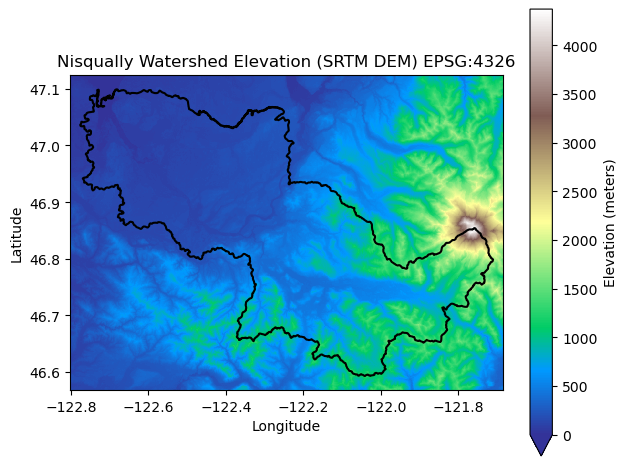

In [ ]:
# Plot with limits for better visualization
nisqually_srtm_da.plot(
    cmap="terrain",
    vmin=0,
    vmax=float(nisqually_srtm_da.max()),
    cbar_kwargs={"label": "Elevation (meters)"}
)

# Add watershed boundary
nisqually_gdf.boundary.plot(ax=plt.gca(), color="black")

# Add title and axis labels
plt.title("Nisqually Watershed Elevation (SRTM DEM) EPSG:4326")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

#### Figure 2: This map shows elevation across the Nisqually River watershed and is used to support input calculations for surface runoff, including slope and flow accumulation. Elevation is highest at Mount Rainier, reaching approximately 4,371 meters, and decreases to sea level at the Puget Sound, creating a strong gradient across the watershed. This gradient influences how water moves across the landscape and contributes to surface runoff patterns.

### USGS National Land Cover Database - Impervious Surface %

In [ ]:
# Path to zip file
zip_path = os.path.join(impervious_dir, "NLCD_84d4ec6e-782d-4ca1-985c-369c3d869faf.zip")

# Unzip to the same directory
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(impervious_dir)

# Check the extracted files
print("Unzipped successfully")

In [ ]:
# List the files in the impervious directory to see the extracted contents
for file in os.listdir(impervious_dir):
    print(file)

In [ ]:
# Find the tif
tif_files = [
    f for f in os.listdir(impervious_dir)
    if f.lower().endswith((".tif", ".tiff"))
]

# Check the tif files found
impervious_path = os.path.join(impervious_dir, tif_files[0])

# Open it
impervious_da = rxr.open_rasterio(impervious_path, masked=True).squeeze()

# Check the dataarray
print(impervious_da)

In [ ]:
# Check CRS, bounds, and resolution
print(impervious_da.rio.crs)
print(impervious_da.rio.bounds())
print(impervious_da.rio.resolution())

In [ ]:
# Reproject to match the DEM and watershed boundary (EPSG:5070)
impervious_5070 = impervious_da.rio.reproject("EPSG:5070")

In [ ]:
# Convert watershed boundary to match the CRS of the impervious raster
nisqually_gdf_5070 = nisqually_gdf.to_crs("EPSG:5070")

# Clip the impervious raster to the watershed boundary
impervious_clip = impervious_5070.rio.clip(
    nisqually_gdf_5070.geometry,
    nisqually_gdf_5070.crs,
    drop=True
)

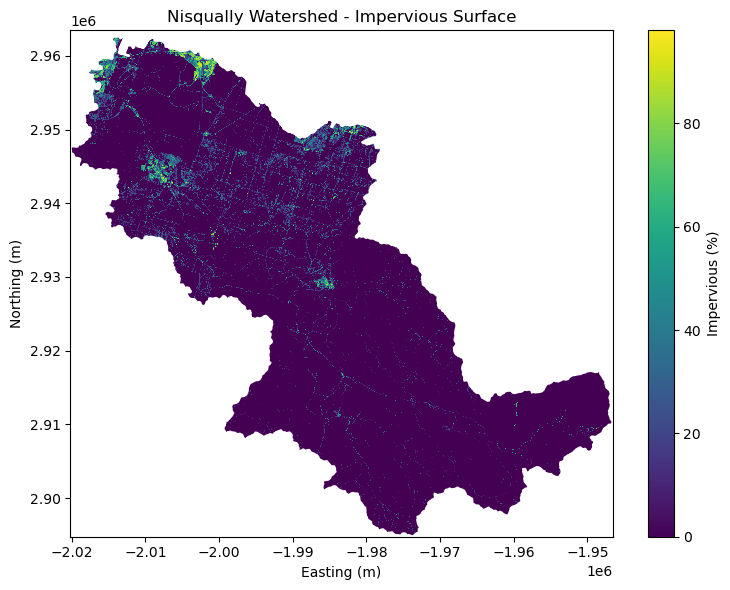

In [ ]:
# Plot the clipped impervious raster
# Set up the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the impervious surface raster with a colormap and colorbar
impervious_clip.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Impervious (%)"}
)

# Plot the watershed boundary on top
nisqually_gdf_5070.boundary.plot(
    ax=ax,
    edgecolor="white",
    linewidth=1.5
)

# Add title and axis labels
ax.set_title("Nisqually Watershed - Impervious Surface")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

#### Figure 3: This map shows the percent of impervious surface in the Nisqually watershed. Higher values are located along roads and in developed areas, including rural towns and more urban areas such as Olympia and Lacey. Impervious surface leads to higher surface runoff because water is unable to infiltrate.

In [ ]:
# Create a function to clean and save the data array to a raster file
def clean_and_save(da, path):
    """Function to clean the data array and save it to a raster file.
    
    Args:
    da (xarray.DataArray): The data array to clean and save
    path (str): The file path to save the raster to
    
    Returns:
    None
    """
    save_da = da.copy()
    save_da.attrs.pop("_FillValue", None)
    save_da.encoding.pop("_FillValue", None)
    save_da = save_da.astype("float32") # Convert to float32
    save_da = save_da.fillna(-9999) # Fill NaN values with -9999 before writing to raster
    save_da = save_da.rio.write_nodata(-9999) # Set the nodata value to -9999 in the raster metadata
    save_da.rio.to_raster(path, dtype="float32") 
    print(f"Saved: {path}")

In [ ]:
# Define the path to save the cleaned and clipped impervious raster
impervious_5070_path = os.path.join(
    impervious_dir,
    "nisqually_impervious_5070.tif"
)

# Clean and save the clipped impervious raster
clean_and_save(impervious_clip, impervious_5070_path)

### MACA Downscaled Climate Dataset

In [29]:
# Create function to convert longitude values
def convert_longitude(longitude):

    """
    Function to convert longitude

    Args:
    longitude:

    Returns:Function to convert longitude
    """
    
    return (longitude - 360) if longitude > 180 else longitude 

In [ ]:
# Create directory for file
climate_pattern = os.path.join(climate_dir, '*.nc')
climate_pattern

In [31]:
# Define some parameters
site_name = "Nisqually"
site_gdf = nisqually_gdf
date_range = "2041_2045"
model = "CCSM4"
rcp_value = "rcp45"
climate_var = "pr"

In [32]:
# Create a maca path
climate_path = os.path.join(
    climate_dir,
    f"maca_{model}_{site_name}_{date_range}_CONUS_daily.nc"
)

In [33]:
# Construct the URL where the climate data lives
climate_url = (
    "http://thredds.northwestknowledge.net:8080/thredds/dodsC"
    "/MACAV2"
    f"/{model}"
    "/macav2metdata"
    f"_{climate_var}"
    f"_{model}_r6i1p1"
    f"_{rcp_value}"
    f"_{date_range}_CONUS"
    "_daily.nc"
)

In [34]:
# Check out the url
climate_url

'http://thredds.northwestknowledge.net:8080/thredds/dodsC/MACAV2/CCSM4/macav2metdata_pr_CCSM4_r6i1p1_rcp45_2041_2045_CONUS_daily.nc'

In [ ]:
# Open the dataset using xarray
ds = xr.open_dataset(climate_url)
print(ds.data_vars)

In [ ]:
# Check if the variable is "pr" or "precipitation" and assign to climate_da
climate_da = ds["pr"] if "pr" in ds.data_vars else ds["precipitation"]
print(climate_da)

In [37]:
# Check remote point values to make sure it looks right
pt_raw = climate_da.sel(lat=46.85, lon=237.8, method="nearest")
print("Remote raw point min/max:", float(pt_raw.min()), float(pt_raw.max()))

Remote raw point min/max: 0.0 92.08182525634766


In [38]:
# Convert longitude values to the range [-180, 180]
climate_da = climate_da.assign_coords(
    lon=(((climate_da.lon + 180) % 360) - 180).data
).sortby("lon")

In [39]:
# Check the converted point values to make sure it looks right
pt_conv = climate_da.sel(lat=46.85, lon=-122.2, method="nearest")
print("Remote converted point min/max:", float(pt_conv.min()), float(pt_conv.max()))

Remote converted point min/max: 0.0 92.08182525634766


In [40]:
# Match the CRS of the climate data to the watershed boundary
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")

# Create a bounding box for the watershed
minx, miny, maxx, maxy = nisqually_4326.total_bounds
print(minx, miny, maxx, maxy)

-122.77620911906662 46.59305184666876 -121.71018763313434 47.09906060599487


In [41]:
# Crop the climate data to the bounding box of the watershed
climate_da_cropped = climate_da.sel(
    lon=slice(minx, maxx),
    lat=slice(miny, maxy)
)

In [42]:
# Check the cropped point values to make sure it looks right
pt_crop = climate_da_cropped.sel(lat=46.85, lon=-122.2, method="nearest")
print("Remote cropped point min/max:", float(pt_crop.min()), float(pt_crop.max()))

# Check the cropped slice values to make sure it looks right
test_crop = climate_da_cropped.isel(time=0)
print("Remote cropped slice min/max:", float(test_crop.min()), float(test_crop.max()))
print(climate_da_cropped.shape)

Remote cropped point min/max: 0.0 92.08182525634766
Remote cropped slice min/max: 2.5459516048431396 17.12653923034668
(1826, 12, 26)


In [43]:
# Load the cropped subset into memory
climate_da_cropped = climate_da_cropped.load()
print("Cropped subset loaded into memory")

Cropped subset loaded into memory


In [ ]:
# Create path for cropped file
cropped_path = os.path.join(
    climate_dir,
    "maca_CCSM4_Nisqually_2041_2045_cropped.nc"
)

if not os.path.exists(cropped_path):
    climate_da_cropped.to_netcdf(cropped_path)
    print("Saved cropped file:", cropped_path)
else:
    print("File already exists, not overwriting:", cropped_path)

In [ ]:
# Check the cropped file by opening it again
ds_check = xr.open_dataset(cropped_path)
print(ds_check.data_vars)

# Check if the variable is "pr" or "precipitation" and assign to check_da
check_da = ds_check["precipitation"] if "precipitation" in ds_check.data_vars else ds_check["pr"]

# Check the cropped point values to make sure it looks right
pt_check = check_da.sel(lat=46.85, lon=-122.2, method="nearest")
print("Local cropped point min/max:", float(pt_check.min()), float(pt_check.max()))

# Check the cropped slice values to make sure it looks right
test_check = check_da.isel(time=0)
print("Local cropped slice min/max:", float(test_check.min()), float(test_check.max()))

In [ ]:
# Plot the mean precipitation to check it out
climate_mean = check_da.mean(dim="time")
climate_mean.plot()

# Add title
plt.title("Mean Precipitation")
plt.show()

In [ ]:
# Check the min and max values of the mean precipitation
print(float(climate_mean.min()), float(climate_mean.max()))

In [ ]:
# Check the shape of the cropped data array
climate_da_cropped.shape

In [49]:
# Create function to get all climate data
# *Created with help of ChatGPT, refined by author*
def get_maca_cropped_precip(
    model,
    scenario,
    date_range,
    watershed_gdf,
    climate_dir,
    site_name="Nisqually",
):
    """
    Function to open a remote MACA daily precipitation dataset for one time chunk,
    convert longitude from 0-360 to -180-180, crop to the watershed
    bounding box, load the cropped daily subset into memory, and save
    it locally as a NetCDF file.

    Args:
    model (str): MACA climate model name, e.g. "CCSM4".
    scenario (str): Scenario name, e.g. "historical", "rcp45", or "rcp85".
    date_range (str): Time chunk string, e.g. "1975_1979" or "2041_2045".
    watershed_gdf (geopandas.GeoDataFrame): Watershed boundary used for cropping.
    climate_dir (str): Directory where the cropped NetCDF file will be saved.
    site_name (str): Name of the study site for use in the output filename. Defaults to "Nisqually".

    Returns
    str: Path to the saved cropped NetCDF file.
    """

    # MACA ensemble convention
    ensemble = "r6i1p1" if model == "CCSM4" else "r1i1p1"

    # Build filename differently for historical vs future scenarios
    if scenario == "historical":
        remote_filename = (
            f"macav2metdata_pr_{model}_{ensemble}_historical_{date_range}_CONUS_daily.nc"
        )
    else:
        remote_filename = (
            f"macav2metdata_pr_{model}_{ensemble}_{scenario}_{date_range}_CONUS_daily.nc"
        )

    # Build remote URL
    climate_url = (
        "http://thredds.northwestknowledge.net:8080/thredds/dodsC"
        f"/MACAV2/{model}/{remote_filename}"
    )

    # Build local output path
    out_path = os.path.join(
        climate_dir,
        f"maca_{model}_{scenario}_{site_name}_{date_range}_cropped.nc"
    )

    # Skip if already exists
    if os.path.exists(out_path):
        print(f"Already exists: {out_path}")
        return out_path

    # Print message about opening remote dataset
    print(f"Opening remote dataset for {scenario} {date_range}...")

    # Open remote dataset
    ds = xr.open_dataset(climate_url)

    # Grab precipitation variable
    climate_da = ds["pr"] if "pr" in ds.data_vars else ds["precipitation"]

    # Convert longitude from 0-360 to -180-180 and sort
    climate_da = climate_da.assign_coords(
        lon=(((climate_da.lon + 180) % 360) - 180).data
    ).sortby("lon")

    # Watershed bounds in EPSG:4326 to match MACA coordinates
    watershed_4326 = watershed_gdf.to_crs("EPSG:4326")
    bounds = watershed_4326.total_bounds

    # Add buffer
    buffer = 0.05
    xmin, ymin, xmax, ymax = bounds
    bounds_buffer = (xmin - buffer, ymin - buffer, xmax + buffer, ymax + buffer)

    # Crop to buffered bounding box
    climate_da_cropped = climate_da.sel(
        lon=slice(bounds_buffer[0], bounds_buffer[2]),
        lat=slice(bounds_buffer[1], bounds_buffer[3])
    )

    # Load cropped subset into memory before saving
    climate_da_cropped = climate_da_cropped.load()

    # Quick sanity check on first day
    test = climate_da_cropped.isel(time=0)
    print("First-day cropped min/max:", float(test.min()), float(test.max()))

    # Save cropped daily data
    climate_da_cropped.to_netcdf(out_path)

    # Close remote dataset
    ds.close()

    print(f"Saved: {out_path}")
    return out_path

In [ ]:
# Make sure function works by running it for one time chunk
test_path = get_maca_cropped_precip(
    model="CCSM4",
    scenario="rcp45",
    date_range="2046_2050",
    watershed_gdf=nisqually_gdf,
    climate_dir=climate_dir,
    site_name="Nisqually"
)

# Check the output path
print(test_path)

In [51]:
# Define historical date range for looping
historical_ranges = [
    "1975_1979",
    "1980_1984",
    "1985_1989",
    "1990_1994",
    "1995_1999",
    "2000_2004",
    "2005_2005",
]

# Define future date range for looping
future_ranges = [
    "2041_2045",
    "2046_2050",
    "2051_2055",
    "2056_2060",
    "2061_2065",
    "2066_2070",
]

In [ ]:
# Create loop for all historical and future time chunks
saved_files = []

# Loop through historical ranges
for tr in historical_ranges:
    saved_files.append(
        get_maca_cropped_precip(
            model="CCSM4",
            scenario="historical",
            date_range=tr,
            watershed_gdf=nisqually_gdf,
            climate_dir=climate_dir,
            site_name="Nisqually",
        )
    )

# Loop through future ranges
for tr in future_ranges:
    saved_files.append(
        get_maca_cropped_precip(
            model="CCSM4",
            scenario="rcp45",
            date_range=tr,
            watershed_gdf=nisqually_gdf,
            climate_dir=climate_dir,
            site_name="Nisqually",
        )
    )

# Check the list of saved files
saved_files

### NRCS Soil Data - Hydrologic Soil Group

In [53]:
# Path to the downloaded zip file
soils_zip_path = os.path.join(soils_dir, "gSSURGO_WA.zip")

# Extracted directory path
soils_extract_dir = os.path.join(soils_dir, "extracted")
os.makedirs(soils_extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(soils_zip_path, 'r') as zip_ref:
    zip_ref.extractall(soils_extract_dir)

# Path to GeoPackage (after unzip)
soils_gpkg_path = os.path.join(soils_extract_dir, "gSSURGO_WA.gdb")

In [ ]:
# Make sure it exists
soils_gdf = gpd.read_file(soils_gpkg_path)

In [ ]:
# Check the map unit attributes layer
map_unit_attributes = gpd.read_file(soils_gpkg_path, layer="muaggatt")

# Check the first few rows of the map unit attributes
map_unit_attributes.head()

# Check the columns in the map unit attributes
map_unit_attributes.columns

In [ ]:
# Read the map unit aggregate attributes table
map_unit_attributes = gpd.read_file(soils_gpkg_path, layer="muaggatt")
map_unit_attributes.columns = map_unit_attributes.columns.str.lower()

# Read the soils polygon layer
soils = gpd.read_file(soils_gpkg_path, layer="MUPOLYGON")
soils.columns = soils.columns.str.lower()

# Keep only the columns needed for this step
map_unit_attributes_subset = map_unit_attributes[["mukey", "hydgrpdcd"]].dropna()

# Join hydrologic group code to soil polygons
soils_gdf = soils.merge(map_unit_attributes_subset, on="mukey", how="left")

# Simplify hydrologic group values like "A/D" to a single group
def simplify_hydgrp(val):
    if pd.isna(val):
        return None
    return val.split("/")[-1]

# Create a cleaned hydrologic group field
soils_gdf["hydgrp"] = soils_gdf["hydgrpdcd"].apply(simplify_hydgrp)

# Quick checks
print(soils_gdf[["mukey", "hydgrpdcd", "hydgrp"]].head())
print(soils_gdf["hydgrp"].value_counts(dropna=False))

In [ ]:
# Check the CRS of the soils geodataframe
# Keep 5070 for analysis, but reproject to 4326 for plotting
soils_gdf.crs

In [ ]:
# Check out whole map of hydrologic soil groups
soils_gdf.plot(column="hydgrp", legend=True)

In [ ]:
# Check out the columns in the soils geodataframe
print(soils_gdf.columns)

In [60]:
# Make sure in same CRS for clipping and plotting
soil_gdf_5070 = soils_gdf.to_crs("EPSG:5070")
nisqually_gdf_5070 = nisqually_gdf.to_crs("EPSG:5070")

In [61]:
# Clip the soil data to the watershed boundary
nisqually_soil_clip = gpd.clip(soil_gdf_5070, nisqually_gdf_5070)

In [ ]:
# Plot the clipped soil data
fig, ax = plt.subplots(figsize=(8,6))

# Plot the soil data with the hydrologic group column and a legend
nisqually_soil_clip.plot(
    column="hydgrp",
    ax=ax,
    legend=True
)

# Add watershed boundary on top
nisqually_gdf_5070.boundary.plot(ax=ax, edgecolor="black")

# Add title
plt.title("Nisqually Watershed - Hydrologic Soil Groups - EPSG:5070")
plt.show()

In [ ]:
# Check the hydrologic group values in the clipped soil data
nisqually_soil_clip["hydgrp"].value_counts(dropna=False)

In [64]:
# create a clean modeling version
nisqually_soil_clean = nisqually_soil_clip.dropna(subset=["hydgrp"]).copy()

In [65]:
# Create soil score mapping based on hydrologic group, where A=0.1, B=0.4, C=0.7, D=1.0
soil_score_map = {
    "A": 0.0,
    "B": 0.37,
    "C": 0.78,
    "D": 1.0
}

# Add soil score column to the cleaned soil geodataframe
nisqually_soil_clean["soil_score"] = nisqually_soil_clean["hydgrp"].map(soil_score_map)

# Make sure there are no missing values in the soil score column
nisqually_soil_clean["soil_score"].isna().sum()  

np.int64(0)

In [66]:
# Check the first few rows of the cleaned soil geodataframe
nisqually_soil_polygons = zip(
    nisqually_soil_clean.geometry.values,
    nisqually_soil_clean["soil_score"].values
)

# Rasterize the soil polygons to create a soil score raster
nisqually_soil_raster = grid.rasterize(nisqually_soil_polygons, fill=np.nan)

In [ ]:
# Create path for soil raster file
soil_raster_path = os.path.join(soils_dir, "nisqually_soil_score_5070.tif")

# Save the soil score raster to a GeoTIFF file
grid.to_raster(nisqually_soil_raster, soil_raster_path)

# Print the path to the saved soil raster
print("Saved soil raster to:", soil_raster_path)

In [68]:
# Open the saved soil raster to check it out
nisqually_soil_da = rxr.open_rasterio(soil_raster_path, masked=True).squeeze()

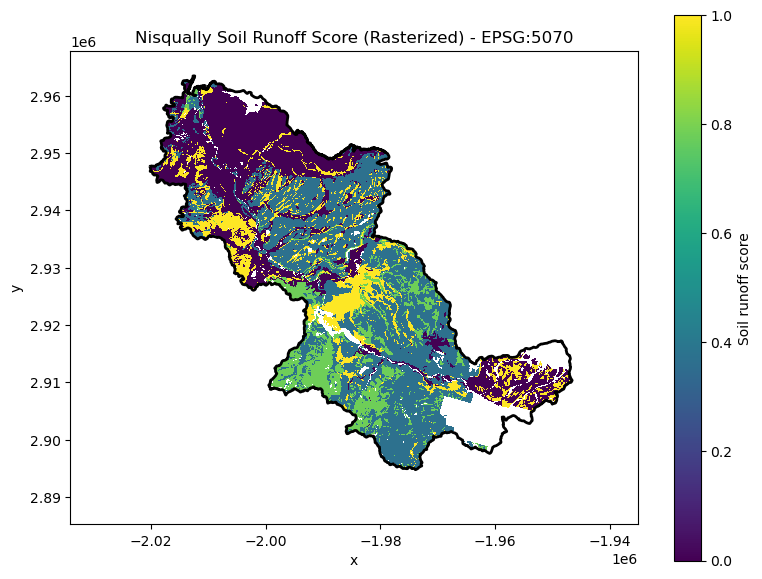

In [69]:
# Plot the soil score raster with the watershed boundary on top
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the soil score raster with a colormap and colorbar
nisqually_soil_da.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Soil runoff score"} # Label for the colorbar
)

# Add watershed boundary on top with white edges
nisqually_gdf_5070.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=2
)

# Add title
ax.set_title("Nisqually Soil Runoff Score (Rasterized) - EPSG:5070")
plt.tight_layout()
plt.show()

#### Figure 4: This map shows hydrologic soil groups (A–D) from NRCS, representing soil types with varying infiltration capacity in the Nisqually watershed. Soil groups range from A (high infiltration) to D (low infiltration) and were converted to a runoff score from 0–1 based on infiltration rate and rasterized to prep for input. Higher runoff scores are generally associated with soils that have higher clay content and slower infiltration, while lower scores are associated with soils that are well-drained and have higher sand or silt content. This data input was incorporated into the model because soil infiltration influences how much precipitation becomes surface runoff in a given area.

#### SRTM Analysis - Derive Slope from DEM

In [70]:
# Reproject the SRTM DEM to 5070 to calculate slope 
nisqually_rpj = nisqually_srtm_da.rio.reproject("EPSG:5070")

# Create a copy of the data array to modify for saving
save_da = nisqually_rpj.copy()

# Remove any existing _FillValue attribute and encoding to avoid issues when writing the raster
save_da.attrs.pop("_FillValue", None)

# Remove any existing _FillValue from encoding and set the nodata value to -9999
save_da.encoding.pop("_FillValue", None)
save_da = save_da.astype("float32").fillna(-9999)

# Write the nodata value to the raster metadata
save_da = save_da.rio.write_nodata(-9999)

# Create the path for the new raster file
dem_5070_path = os.path.join(topography_dir, "nisqually_dem_5070.tif")

# Save the raster as float32 with nodata value of -9999
save_da.rio.to_raster(dem_5070_path, dtype="float32")

In [71]:
# Open the reprojected DEM to check it out
dem_5070 = rxr.open_rasterio(dem_5070_path, masked=True).squeeze()

In [72]:
# Calculate slope
nisqually_slope = xrspatial.slope(dem_5070)

In [73]:
slope_5070_path = os.path.join(topography_dir, "nisqually_slope_5070.tif")

save_da = nisqually_slope.copy()
save_da.attrs.pop("_FillValue", None)
save_da.encoding.pop("_FillValue", None)
save_da = save_da.astype("float32").fillna(-9999)
save_da = save_da.rio.write_nodata(-9999)

save_da.rio.to_raster(slope_5070_path, dtype="float32")

In [74]:
def reproject_4326(input_path, output_path=None, dst_crs="EPSG:4326"):
    """
    Reproject a raster to a new CRS and save it to a new file for plotting.

    Args:
        input_path (str): Path to the input raster file.
        output_path (str): Path to the output raster file. If None, saves with "_4326" suffix.
        dst_crs (str): Target CRS. Default is "EPSG:4326".

    Returns:
        str: Path to the saved reprojected raster file.
    """

    # Open raster
    da = rxr.open_rasterio(input_path, masked=True).squeeze()

    # Reproject
    da_reprojected = da.rio.reproject(dst_crs)

    # Create output path if not provided
    if output_path is None:
        base, ext = os.path.splitext(input_path)
        base = base.replace("_5070", "")
        output_path = f"{base}_4326{ext}"

    # Clean + standardize before saving
    save_da = da_reprojected.copy()
    save_da.attrs.pop("_FillValue", None)
    save_da.encoding.pop("_FillValue", None)
    save_da = save_da.astype("float32")
    save_da = save_da.fillna(-9999)
    save_da = save_da.rio.write_nodata(-9999)

    # Save
    save_da.rio.to_raster(output_path, dtype="float32")

    print(f"Reprojected raster saved to: {output_path}")
    return output_path

In [75]:
# Reproject slope to 4326 for plotting
nisqually_slope_4326_path = reproject_4326(slope_5070_path)

# Open the reprojected slope raster to check it out
nisqually_slope_4326 = rxr.open_rasterio(nisqually_slope_4326_path, masked=True).squeeze()

Reprojected raster saved to: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\topography\nisqually_slope_4326.tif


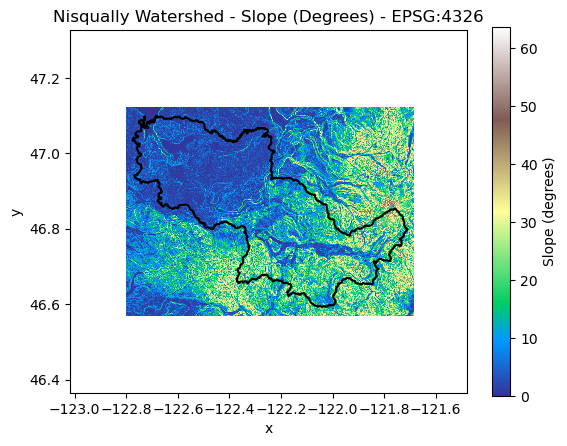

In [76]:
# Plot slope with watershed boundary
fig, ax = plt.subplots()

# Plot slope with a terrain colormap and colorbar with label
nisqually_slope_4326.plot(
    ax=ax,
    cmap='terrain',
    cbar_kwargs={'label': 'Slope (degrees)'}
)

# Add title
ax.set_title("Nisqually Watershed - Slope (Degrees) - EPSG:4326")

# Plot watershed boundary on top
nisqually_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

# Show the plot
plt.show()

#### Figure 5: This map shows the derived topographic slope in the Nisqually watershed. Slope is more variable and steeper in the mountainous terrain. Steeper slopes promote faster runoff and reduce the opportunity for infiltration, making slope an important input for assessing surface runoff susceptibility and risk.

#### Derive Flow Accumulation from DEM

In [77]:
# Read the DEM raster using pysheds
grid = Grid.from_raster(dem_5070_path)
dem = grid.read_raster(dem_5070_path)

In [78]:
# Condition DEM to fill depressions and calculate flow direction
# Fill pits in the DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in the DEM
flood_dem = grid.fill_depressions(pit_filled_dem)

# Resolve flats in the DEM
inflated_dem = grid.resolve_flats(flood_dem)


In [79]:
# Determmine D8 flow direction from DEM
# Specify directional mapping
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)

# Compute flow directions 
fdir = grid.flowdir(inflated_dem, dirmap=dirmap)

In [ ]:
# Replace 0 values with NaN for better visualization
fdir_plot = np.where(fdir == 0, np.nan, fdir)

# Plot flow direction with watershed boundary on top
fig, ax = plt.subplots(figsize=(8,6))

# Plot flow direction with a colormap and colorbar with label
im = ax.imshow(
    fdir_plot,
    extent=grid.extent,
    cmap='viridis',
    zorder=2 # Set zorder to plot below the watershed boundary
)

# Add watershed boundary on top
nisqually_gdf_5070.boundary.plot(ax=ax, edgecolor="white")

# Add colorbar with ticks corresponding to flow direction values
boundaries = [0] + sorted(list(dirmap))
plt.colorbar(im, boundaries=boundaries, values=sorted(dirmap))

# Add title and labels
ax.set_title('Flow direction grid', size=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.grid(zorder=-1) # Add gridlines behind the plot

plt.tight_layout()
plt.show()

In [81]:
# Calcuate flow accumulation
acc = grid.accumulation(fdir, dirmap=dirmap)

In [82]:
# Save the flow accumulation raster
flow_acc_path = os.path.join(topography_dir, "nisqually_flow_acc_5070.tif")
grid.to_raster(acc, flow_acc_path)

# Show the path to the saved flow accumulation raster
print("Flow accumulation raster saved to:", flow_acc_path)

Flow accumulation raster saved to: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\topography\nisqually_flow_acc_5070.tif


C:\Users\nymve\AppData\Local\Temp\ipykernel_19548\3925235238.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cubehelix").copy()


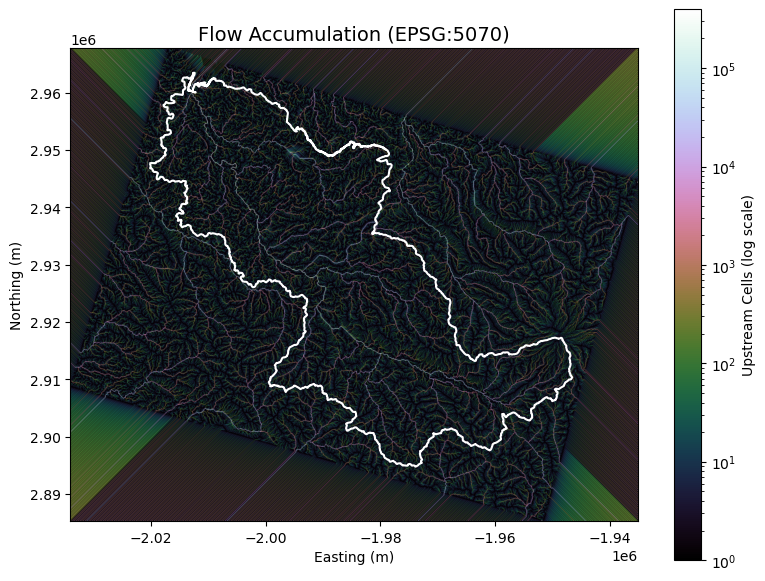

In [83]:
# Open saved 5070 flow accumulation raster
nisqually_flow_acc = rxr.open_rasterio(flow_acc_path, masked=True).squeeze()

# Mask zeros for log scale
acc_plot = np.where(nisqually_flow_acc <= 0, np.nan, nisqually_flow_acc)

# Colormap
cmap = cm.get_cmap("cubehelix").copy()
cmap.set_bad("white")

# Bounds for imshow need order: left, right, bottom, top
left, bottom, right, top = nisqually_flow_acc.rio.bounds()

# Plot flow accumulation with log scale
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)
ax.grid(zorder=0)

im = ax.imshow(
    acc_plot,
    extent=(left, right, bottom, top),
    cmap=cmap,
    norm=colors.LogNorm(vmin=1, vmax=np.nanmax(acc_plot)),
    interpolation="bilinear",
    zorder=2
)

# Add watershed boundary on top
nisqually_gdf_5070.boundary.plot(ax=ax, edgecolor="white")

plt.colorbar(im, ax=ax, label="Upstream Cells (log scale)")
ax.set_title("Flow Accumulation (EPSG:5070)", size=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()

#### Figure 6: This map shows where water is most likely to accumulate across the landscape in the Nisqually watershed, derived from the Digital Elevation Model (DEM). Branching patterns represent stream and river networks where water converges. Flow accumulation is important for surface runoff susceptibility because it shows where water collects across the landscape.

### Process MACA Climate Data <br> Calculate Mean Wet-Season Precipitation and Mean Rx1day <br> Subset to Historical (1976-2005) & Future Climate Scenarios (2041-2070)

In [ ]:
# Historical files only
hist_files = sorted([
    str(f) for f in saved_files
    if "maca_CCSM4_historical_Nisqually" in Path(f).name
])

# Future files only
fut_files = sorted([
    str(f) for f in saved_files
    if "maca_CCSM4_rcp45_Nisqually" in Path(f).name
])

# Quick check of the files
print(len(hist_files), len(fut_files))
print(hist_files[:2])
print(fut_files[:2])

# Open the historical and future datasets as xarray multi-file datasets
ds_hist = xr.open_mfdataset(hist_files, combine="by_coords")
ds_fut = xr.open_mfdataset(fut_files, combine="by_coords")

In [85]:
# Check the data variables in each dataset to see if it's "pr" or "precipitation"
pr_hist = ds_hist["pr"] if "pr" in ds_hist.data_vars else ds_hist["precipitation"]
pr_fut  = ds_fut["pr"] if "pr" in ds_fut.data_vars else ds_fut["precipitation"]

In [86]:
# Subset to years 1976-2005
pr_hist = pr_hist.sel(time=slice("1976-01-01", "2005-12-31"))

# Subset to years 2041-2070
pr_fut = pr_fut.sel(time=slice("2041-01-01", "2070-12-31"))

In [ ]:
# Check out that it worked 
print(pr_hist.time.min().values, pr_hist.time.max().values)
print(len(pr_hist.time))

In [88]:
# Create function to calculate wet season mean 
def wet_season_mean_raster(da):
    """
    Calculate mean daily precipitation during the wet season (DJF).

    Args:
        da (xarray.DataArray): Daily precipitation with time dimension

    Returns:
        xarray.DataArray: Mean DJF precipitation raster (mm/day)
    """
    da_wet = da.sel(time=da["time.season"] == "DJF")
    return da_wet.mean(dim="time")

In [89]:
# Calculate the wet season mean raster - historical
pr_hist_wet_mean = wet_season_mean_raster(pr_hist)

# Calculate the wet season mean raster - future
pr_future_wet_mean = wet_season_mean_raster(pr_fut)

In [ ]:
# Create figure and axis for plotting historical
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the historical wet-season mean precipitation raster
pr_hist_wet_mean.plot(
    ax=ax,
    cmap="Blues", # Blue color scale
    cbar_kwargs={"label": "Mean DJF precipitation (mm/day)"} # Add label
)

# Convert watershed boundary to match raster CRS (EPSG:4326)
# and overlay it on the map for spatial reference
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")
nisqually_4326.boundary.plot(ax=ax, color="black", linewidth=1)

# Add a visual buffer around the raster extent
buffer = 0.1

# Expand x-axis limits
ax.set_xlim(
    float(pr_hist_wet_mean.lon.min()) - buffer,
    float(pr_hist_wet_mean.lon.max()) + buffer
)

# Expand y-axis limits
ax.set_ylim(
    float(pr_hist_wet_mean.lat.min()) - buffer,
    float(pr_hist_wet_mean.lat.max()) + buffer
)

# Add a descriptive title for the map
ax.set_title("Historical Mean Wet-Season Precipitation (1976–2005)")

# Display the plot
plt.show()

In [ ]:
# Create figure and axis for plotting future
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the future wet-season mean precipitation raster
pr_future_wet_mean.plot(
    ax=ax,
    cmap="Blues",  # Blue color scale
    cbar_kwargs={"label": "Mean DJF precipitation (mm/day)"}  # Add label
)

# Convert watershed boundary to match raster CRS (EPSG:4326)
# and overlay it on the map for spatial reference
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")
nisqually_4326.boundary.plot(ax=ax, color="black", linewidth=1)

# Add a visual buffer around the raster extent
buffer = 0.1

# Expand x-axis limits (longitude)
ax.set_xlim(
    float(pr_future_wet_mean.lon.min()) - buffer,
    float(pr_future_wet_mean.lon.max()) + buffer
)

# Expand y-axis limits (latitude)
ax.set_ylim(
    float(pr_future_wet_mean.lat.min()) - buffer,
    float(pr_future_wet_mean.lat.max()) + buffer
)

# Add a descriptive title for the map
ax.set_title("Future Mean Wet-Season Precipitation (2041–2070)")

# Display the plot
plt.show()

In [ ]:
# Calculate the difference between future and historical wet-season precipitation
# Positive values indicate an increase in precipitation
delta_pr = pr_future_wet_mean - pr_hist_wet_mean

# Create figure and axis for plotting the difference map
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the difference raster
delta_pr.plot(
    ax=ax,
    cmap="RdBu", # Diverging colormap  (red = decrease, blue = increase)
    vmin=-1.2, # Set color scale evenly
    vmax=1.2,  # Set color scale evenly
    cbar_kwargs={"label": "Change in precipitation (mm/day)"}
)

# Add a descriptive title explaining the comparison
ax.set_title("Change in Mean Wet-Season Precipitation\n(2041–2070 minus 1976–2005)")

# Overlay watershed boundary for spatial reference
nisqually_gdf.to_crs("EPSG:4326").boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)

# Display the plot
plt.show()

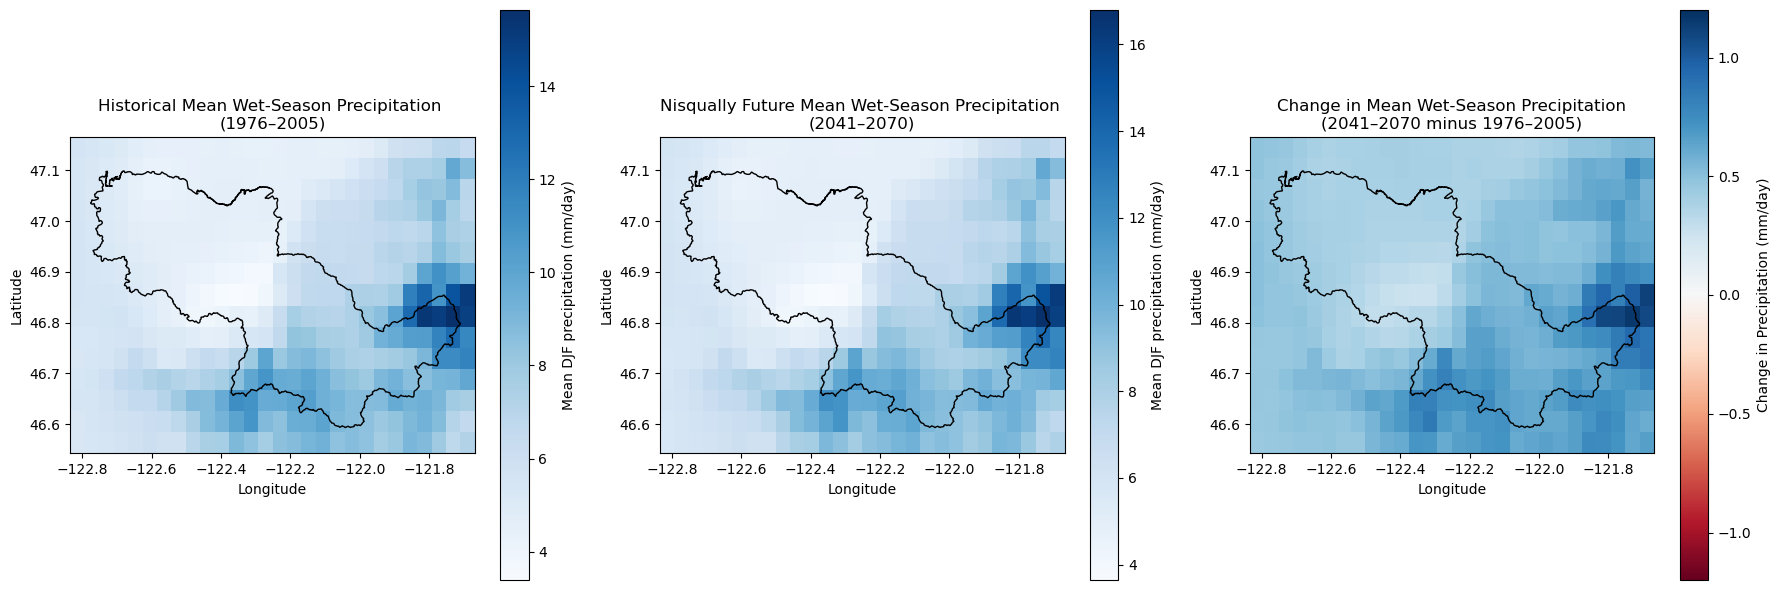

In [130]:
# Create figure with 3 subplots (side by side)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Reproject boundary once
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")

# Historical plot
pr_hist_wet_mean.plot(
    ax=axes[0],
    cmap="Blues",
    cbar_kwargs={"label": "Mean DJF precipitation (mm/day)"}
)

nisqually_4326.boundary.plot(ax=axes[0], color="black", linewidth=1)
axes[0].set_title("Historical Mean Wet-Season Precipitation \n(1976–2005)")

# Future plot
pr_future_wet_mean.plot(
    ax=axes[1],
    cmap="Blues",
    cbar_kwargs={"label": "Mean DJF precipitation (mm/day)"}
)

nisqually_4326.boundary.plot(ax=axes[1], color="black", linewidth=1)
axes[1].set_title("Nisqually Future Mean Wet-Season Precipitation \n(2041–2070)")

# Difference Comparison plot
portfolio_delta_pr = pr_future_wet_mean - pr_hist_wet_mean

portfolio_delta_pr.plot(
    ax=axes[2],
    cmap="RdBu",
    vmin=-1.2,
    vmax=1.2,
    cbar_kwargs={"label": "Change in Precipitation (mm/day)"}
)

nisqually_4326.boundary.plot(ax=axes[2], color="black", linewidth=1)
axes[2].set_title("Change in Mean Wet-Season Precipitation\n(2041–2070 minus 1976–2005)")


# Clean up axes
for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

#### Figure 7: This set of maps shows the mean wet-season precipitation (Dec–Feb) under historical (1976–2005) and future conditions (2041–2070) in the Nisqually watershed. In both scenarios, precipitation is highest at Mount Rainier and in the mountainous areas, which includes snowfall, and generally decreases toward the lower elevation areas of the watershed. The map on the right shows the change, with the entire watershed showing an increase in precipitation, consistent with regional climate projections. The greatest increases occur in the mountains and near the mouth of the river, while the central portion of the watershed shows the least change and precipitation overall. This could reflect a mid-elevation zone that is not as drastically influenced as the coast and mountainous regions. Wet-season precipitation is an important input to the fuzzy logic model because it represents the overall water input to the system, which influences soil saturation and the potential for surface runoff generation. Increased precipitation can lead to increased surface runoff, particularly in areas that are already prone to runoff.

In [ ]:
# Double check min / max values
print(float(delta_pr.min()))
print(float(delta_pr.max()))

##### Rx1day Climate Calculation - Storm Intensity Proxy

In [94]:
# Historical Rx1day calculations
# Subset to highest day in a year
annual_max_hist = pr_hist.resample(time="YE").max()

# Take the mean of all the years Rx1day
rx1day_hist_mean = annual_max_hist.mean(dim="time")

# Future Rx1day calculations
# Subset to highest day in a year
annual_max_fut = pr_fut.resample(time="YE").max()

# Take the mean of all the years Rx1day
rx1day_fut_mean = annual_max_fut.mean(dim="time")

In [95]:
# Check out the min/max to make sure the values make sense
print("Historical Rx1day min/max:")
print(float(rx1day_hist_mean.min()), float(rx1day_hist_mean.max()))

print("Future Rx1day min/max:")
print(float(rx1day_fut_mean.min()), float(rx1day_fut_mean.max()))

Historical Rx1day min/max:
35.734840393066406 135.65138244628906
Future Rx1day min/max:
33.55461120605469 141.6044158935547


In [ ]:
# Create figure and axis for plotting historical Rx1day
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the historical Rx1day raster
rx1day_hist_mean.plot(
    ax=ax,
    cmap="Purples",  # Good for extreme values
    cbar_kwargs={"label": "Rx1day (mm/day)"}  # Add label
)

# Overlay watershed boundary
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")
nisqually_4326.boundary.plot(ax=ax, color="black", linewidth=1)

# Add title
ax.set_title("Historical Rx1day (1976–2005)")

# Display plot
plt.show()

In [ ]:
# Create figure and axis for plotting future Rx1day
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the future Rx1day raster
rx1day_fut_mean.plot(
    ax=ax,
    cmap="Purples",
    cbar_kwargs={"label": "Rx1day (mm/day)"}
)

# Overlay watershed boundary
nisqually_4326.boundary.plot(ax=ax, color="black", linewidth=1)

# Add title
ax.set_title("Future Rx1day (2041–2070)")

# Display plot
plt.show()

In [ ]:
# Calculate the difference between future and historical wet-season precipitation
# Positive values indicate an increase in precipitation
change_pr_max = rx1day_fut_mean - rx1day_hist_mean

# Create figure and axis for plotting the difference map
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the difference raster
change_pr_max.plot(
    ax=ax,
    cmap="RdBu", # Diverging colormap  (red = decrease, blue = increase)
    vmin=-10, # Set color scale evenly
    vmax=10,  # Set color scale evenly
    cbar_kwargs={"label": "Change in precipitation (mm/day)"}
)

# Add a descriptive title explaining the comparison
ax.set_title("Change in Rx1day Mean Precipitation - Intensity Proxy \n(2041–2070 minus 1976–2005)")

# Overlay watershed boundary for spatial reference
nisqually_gdf.to_crs("EPSG:4326").boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)

# Display the plot
plt.show()

In [ ]:
# Check out the min/max values to make sure they make sense
float(change_pr_max.min()), float(change_pr_max.max())

(-6.457672119140625, 10.438812255859375)

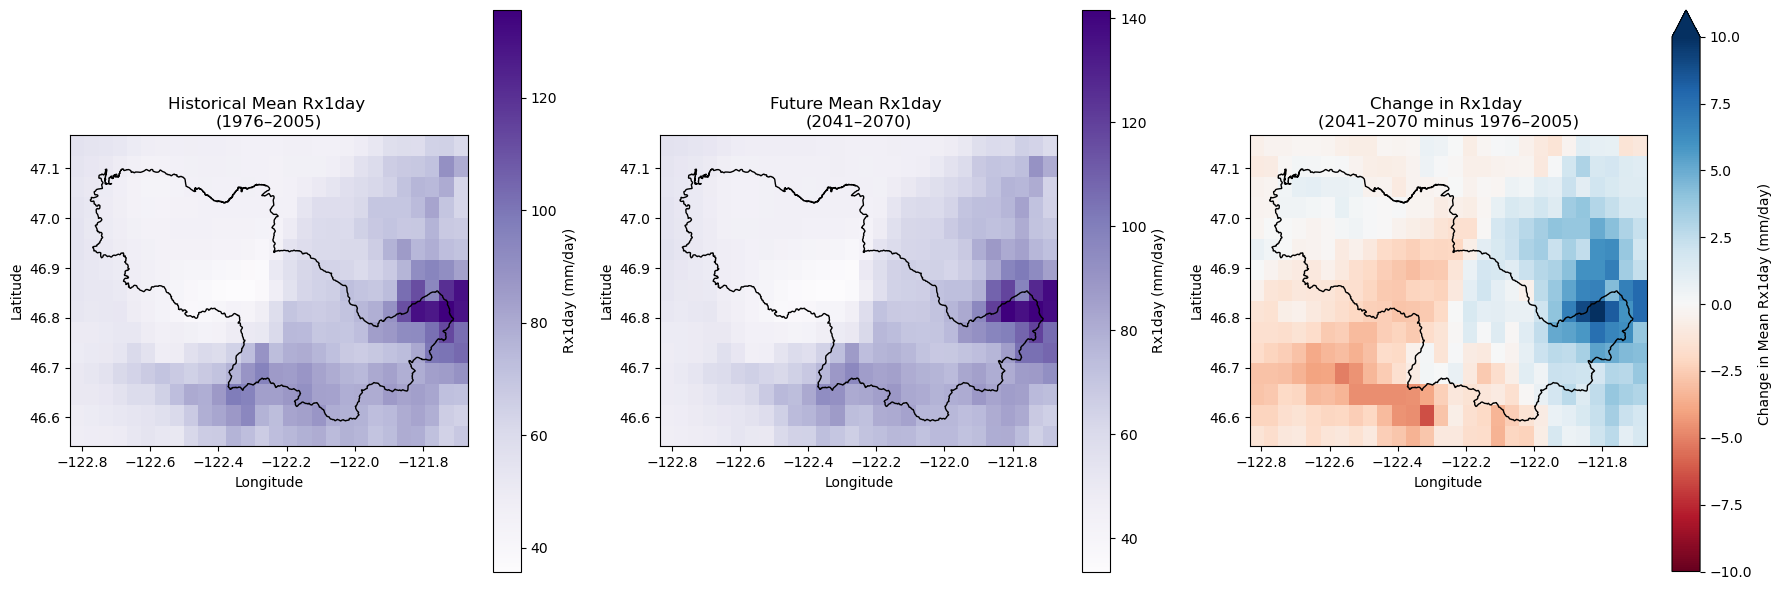

In [136]:
# Create figure with 3 subplots (side by side)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Reproject boundary once
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")

# Historical plot
rx1day_hist_mean.plot(
    ax=axes[0],
    cmap="Purples",
    cbar_kwargs={"label": "Rx1day (mm/day)"}
)

nisqually_4326.boundary.plot(ax=axes[0], color="black", linewidth=1)
axes[0].set_title("Historical Mean Rx1day \n(1976–2005)")

# Future plot
rx1day_fut_mean.plot(
    ax=axes[1],
    cmap="Purples",
    cbar_kwargs={"label": "Rx1day (mm/day)"}
)

nisqually_4326.boundary.plot(ax=axes[1], color="black", linewidth=1)
axes[1].set_title("Future Mean Rx1day \n(2041–2070)")

# Difference comparison plot
portfolio_change_rx1day = rx1day_fut_mean - rx1day_hist_mean

portfolio_change_rx1day.plot(
    ax=axes[2],
    cmap="RdBu",
    vmin=-10,
    vmax=10,
    cbar_kwargs={"label": "Change in Mean Rx1day (mm/day)"}
)

nisqually_4326.boundary.plot(ax=axes[2], color="black", linewidth=1)
axes[2].set_title("Change in Rx1day \n(2041–2070 minus 1976–2005)")

# Clean up axes
for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

##### Figure 8: This set of maps shows the calculated mean Rx1day for two time periods, a historical period (1976–2005) and a future climate projection (2041–2070), in the Nisqually watershed. Rx1day was incorporated as an input as a proxy for storm intensity and extreme rainfall. In both scenarios, the highest mean Rx1day values occur in the mountainous regions, with values generally decreasing toward the lower elevation areas near the ocean. While it is not immediately apparent when comparing the individual historical and future maps, the change map highlights that not all areas of the watershed will experience an increase in Rx1day, with the central watershed showing a modest decrease. However, the increases are greater in the areas that do experience change. This input is important to the fuzzy logic model because it represents storm intensity and extreme rainfall, and short-duration, high-intensity events can exceed soil infiltration capacity, leading to rapid surface runoff and increased flood potential during these periods.

In [99]:
# Create function to prepare raster for export
# *Created with help of ChatGPT, refined by author*
def prep_raster_for_export(da, x_dim="lon", y_dim="lat", crs="EPSG:4326"):
    """
    Set spatial dimensions and CRS on a DataArray before export.

    Args:
        da (xarray.DataArray): DataArray to prepare
        x_dim (str): Name of longitude dimension. Default is "lon".
        y_dim (str): Name of latitude dimension. Default is "lat".
        crs (str): Coordinate reference system to set. Default is "EPSG:4326".

    Returns:
        xarray.DataArray: Prepared DataArray with spatial metadata
    """
    # Set spatial dimensions and CRS using rioxarray
    da = da.rio.set_spatial_dims(x_dim=x_dim, y_dim=y_dim)
    da = da.rio.write_crs(crs)
    return da

In [100]:
# Calculate the paths for all climate rasters to be exported
# Calculate mean wet season precipitation
pr_hist_wet_mean = prep_raster_for_export(pr_hist_wet_mean)
pr_fut_wet_mean = prep_raster_for_export(pr_future_wet_mean)

# Calculate mean Rx1day
rx1day_hist_mean = prep_raster_for_export(rx1day_hist_mean)
rx1day_fut_mean = prep_raster_for_export(rx1day_fut_mean)

In [101]:
# Check that the spatial dimensions and CRS are set correctly
print(pr_hist_wet_mean.rio.crs)
print(pr_hist_wet_mean.rio.x_dim, pr_hist_wet_mean.rio.y_dim)

EPSG:4326
lon lat


In [102]:
# Create function to write raster
def write_raster(da, out_path):
    """
    Save a climate xarray DataArray as a GeoTIFF raster.

    Args:
        da (xarray.DataArray): Raster to export
        out_path (str): File path for output GeoTIFF

    Returns:
        None
    """

    # Save the calculated raster to a GeoTIFF file
    da.rio.to_raster(out_path)
    print(f"Saved: {out_path}")

In [ ]:
# Save the rasters as GeoTIFFs for plotting
write_raster(pr_hist_wet_mean, os.path.join(climate_dir, "pr_hist_djf_mean_4326.tif"))
write_raster(pr_future_wet_mean, os.path.join(climate_dir, "pr_fut_djf_mean_4326.tif"))
write_raster(rx1day_hist_mean, os.path.join(climate_dir, "rx1day_hist_mean_4326.tif"))
write_raster(rx1day_fut_mean, os.path.join(climate_dir, "rx1day_fut_mean_4326.tif"))

#### Conclusion

Surface runoff susceptibility is generally highest in areas characterized by steeper slopes, lower soil infiltration rates, higher precipitation, higher rainfall intensity, greater flow accumulation, and developed areas. The input variables processed and harmonized for the fuzzy logic model exhibit clear spatial patterns across the Nisqually watershed. 

Steeper slopes are concentrated in the mountainous regions, while higher precipitation and rainfall intensity also tend to occur in these areas. Differences in soil infiltration rates are scattered throughout. Higher values of flow accumulation are observed along stream networks, and developed areas show increased impervious surfaces. These inputs and patterns provide insight into how different landscape characteristics vary spatially across the watershed. 

Future decisions will need to be made regarding fuzzy logic membership function choices, including distribution types, which will be anchored in further research. From these preliminary results, I expect to see areas with already high runoff susceptibility to increase, and areas with low or moderate runoff susceptibility to potentially increase slightly.  I am interested in seeing the results of the overall surface runoff susceptibility map and model. 

This project and approach could be used as a screening tool for mapping surface runoff with a simpler model approach that could be scaled and replicated to inform decision-makers for development planning, mitigation, and risk management. Understanding the current surface runoff susceptibility and comparing that to climate projections helps us create resilient communities and infrastructure, while offering tools to make data-driven decisions. 


#### <u>Further Code & Analysis for Harmonization Below</u>

##### Harmonization for Fuzzy Logic Model <br> Define reference raster - DEM Raster | ESPG:5070

In [104]:
# Open one of the saved rasters to create reference raster for harmonization
reference_raster_dem = rxr.open_rasterio(
    os.path.join(topography_dir, "nisqually_dem_5070.tif")
).squeeze()

In [105]:
# Load and inspect all rasters, comparing to the reference DEM raster 
reference_raster_dem.name = "reference_dem"

In [ ]:
# Check the shape, CRS, resolution, bounds, and name of the reference raster
print(reference_raster_dem.shape) # Shape (height, width)
print(reference_raster_dem.rio.crs) # CRS check
print(reference_raster_dem.rio.resolution()) # Resolution (pixel size in x and y)
print(reference_raster_dem.rio.bounds()) # Bounds (left, bottom, right, top)
print(reference_raster_dem.name) # Name of the DataArray

#### Load and Inspect original rasters

In [107]:
# Create function to load and inspect a raster comparison to reference raster
# *Created with help of ChatGPT, refined by author*
def load_and_inspect_raster(path, name=None, default_crs=None, reference=None):
    """
    Load a single-band raster and inspect metadata important for harmonization.

    Args:
        path (str): Full path to raster file.
        name (str, optional): Custom name to assign to the raster.
        default_crs (str, optional): CRS to assign only if missing.
        reference (xarray.DataArray, optional): Reference raster for comparison.

    Returns:
        xarray.DataArray
    """

    # Open raster with rioxarray and squeeze to 2D if it has a band dimension
    da = rxr.open_rasterio(path).squeeze()

    # Assign name if provided
    if name is not None:
        da.name = name

    # Check if CRS is missing and assign default if provided
    if da.rio.crs is None:
        if default_crs is None:
            print(f"WARNING: {name or path} has no CRS assigned.")
        else:
            da = da.rio.write_crs(default_crs)
            print(f"WARNING: {name or path} had no CRS. Assigned {default_crs}.")

    # Inspect raster metadata
    print("\n----- Raster Inspection -----")
    print(f"Name:       {da.name}") # Name of the DataArray
    print(f"Shape:      {da.shape}") # Shape (height, width)
    print(f"Dimensions: {da.dims}") # Check dimensions
    print(f"CRS:        {da.rio.crs}") # CRS check
    print(f"Resolution: {da.rio.resolution()}") # Resolution (pixel size in x and y)
    print(f"Bounds:     {da.rio.bounds()}") # Bounds (left, bottom, right, top)
    print(f"Dtype:      {da.dtype}") # Data type of the raster values
    print(f"NoData:     {da.rio.nodata}") # NoData value

    # Compare to reference raster
    if reference is not None:
        print("\n--- Compared to Reference ---")
        print(f"Reference:       {reference.name}") # Name of the reference raster
        print(f"Same CRS:        {da.rio.crs == reference.rio.crs}") # CRS match
        print(f"Same Shape:      {da.shape == reference.shape}") # Shape match
        print(f"Same Resolution: {da.rio.resolution() == reference.rio.resolution()}") # Resolution match
        print(f"Same Bounds:     {da.rio.bounds() == reference.rio.bounds()}") # Bounds/extent match

    # Return the loaded DataArray
    return da

In [ ]:
# Create a dictionary of raster names and paths for loading and inspection
rasters = {
    "dem": os.path.join(topography_dir, "nisqually_dem_5070.tif"),
    "slope": os.path.join(topography_dir, "nisqually_slope_5070.tif"),
    "flow_acc": os.path.join(topography_dir, "nisqually_flow_acc_5070.tif"),
    "soil_score": os.path.join(soils_dir, "nisqually_soil_score_5070.tif"),
    "pr_hist_djf_mean": os.path.join(climate_dir, "pr_hist_djf_mean_4326.tif"),
    "pr_fut_djf_mean": os.path.join(climate_dir, "pr_fut_djf_mean_4326.tif"),
    "rx1day_hist_mean": os.path.join(climate_dir, "rx1day_hist_mean_4326.tif"),
    "rx1day_fut_mean": os.path.join(climate_dir, "rx1day_fut_mean_4326.tif"),
}

# Create an empty dictionary to store the loaded rasters
loaded = {}

# Loop through the rasters, load and inspect each one, and store in the loaded dictionary
for name, path in rasters.items():
    if not os.path.exists(path):
        print(f"WARNING: File not found for {name}: {path}")
        continue

    # Use the load_and_inspect_raster to compare to the reference DEM raster
    loaded[name] = load_and_inspect_raster(
        path=path,
        name=name,
        reference=reference_raster_dem
    )

#### Harmonize Climate Rasters

In [109]:
# Create a function to harmonize climate rasters to match the reference DEM raster
def harmonize_climate_reference(path, name, reference_dem, input_crs="EPSG:4326"):
    """Function to load the climate rasters, check/assign CRS, and reproject
    to match the reference DEM raster.
    
    Args:
        path (str): Path to the input climate raster.
        name (str): Name to assign to the loaded DataArray.
        reference_dem (xarray.DataArray): Reference DEM raster to match.
        input_crs (str): CRS to assign if the input raster is missing CRS. Default is "EPSG:4326".
        
        Returns:
            xarray.DataArray: Harmonized climate raster matching the reference DEM."""
    
    da = rxr.open_rasterio(path).squeeze()
    da.name = name

    if da.rio.crs is None:
        da = da.rio.write_crs(input_crs)
        print(f"Assigned missing CRS {input_crs} to {name}")

    da_harmonized = da.rio.reproject_match(
        reference_dem,
        resampling=Resampling.bilinear
    )

    da_harmonized.name = name

    if da_harmonized.ndim == 3:
        da_harmonized = da_harmonized.squeeze()

    return da_harmonized

In [110]:
#
harmonized_rasters = {
    "dem": loaded["dem"],
    "slope": loaded["slope"],
    "flow_acc": loaded["flow_acc"],
    "soil_score": loaded["soil_score"],
}

climate_vars = [
    "pr_hist_djf_mean",
    "pr_fut_djf_mean",
    "rx1day_hist_mean",
    "rx1day_fut_mean"
]

for name in climate_vars:
    harmonized_rasters[name] = harmonize_climate_reference(
        path=rasters[name],
        name=name,
        reference_dem=reference_raster_dem
    )

Assigned missing CRS EPSG:4326 to pr_fut_djf_mean


In [111]:
# Quick check of the harmonized rasters are xarray DataArrays
for name in climate_vars:
    print(name, type(harmonized_rasters[name]))

pr_hist_djf_mean <class 'xarray.core.dataarray.DataArray'>
pr_fut_djf_mean <class 'xarray.core.dataarray.DataArray'>
rx1day_hist_mean <class 'xarray.core.dataarray.DataArray'>
rx1day_fut_mean <class 'xarray.core.dataarray.DataArray'>


#### Inspect Harmonized Climate Rasters

In [ ]:
# Loop to check the harmonized climate rasters and compare to the reference DEM raster
for name in climate_vars:
    da = harmonized_rasters[name]

    print("\n----- Raster Inspection -----")
    print(f"Name:       {name}") # Name of the raster
    print(f"Shape:      {da.shape}") # Check Shape
    print(f"CRS:        {da.rio.crs}") # Check CRS
    print(f"Resolution: {da.rio.resolution()}") # Check resolution / cell size
    print(f"Bounds:     {da.rio.bounds()}") # Check bounds & extent

    print("\n--- Compared to Reference ---")
    print(f"Same CRS:        {da.rio.crs == reference_raster_dem.rio.crs}") # Check if CRS matches reference DEM
    print(f"Same Shape:      {da.shape == reference_raster_dem.shape}") # Check if shape matches reference DEM
    print(f"Same Resolution: {da.rio.resolution() == reference_raster_dem.rio.resolution()}") # Check if resolution matches reference DEM
    print(f"Same Bounds:     {da.rio.bounds() == reference_raster_dem.rio.bounds()}") # Check if bounds match reference DEM

#### Save Harmonized Climate Rasters

In [113]:
# Create output paths for harmonized climate rasters
harmonized_climate_paths = {
    "pr_hist_djf_mean": os.path.join(climate_dir, "pr_hist_djf_mean_5070.tif"),
    "pr_fut_djf_mean": os.path.join(climate_dir, "pr_fut_djf_mean_5070.tif"),
    "rx1day_hist_mean": os.path.join(climate_dir, "rx1day_hist_mean_5070.tif"),
    "rx1day_fut_mean": os.path.join(climate_dir, "rx1day_fut_mean_5070.tif"),
}

# Save harmonized climate rasters
for name, path in harmonized_climate_paths.items():
    harmonized_rasters[name].rio.to_raster(path)
    print(f"Saved {name} to {path}")

Saved pr_hist_djf_mean to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\pr_hist_djf_mean_5070.tif
Saved pr_fut_djf_mean to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\pr_fut_djf_mean_5070.tif
Saved rx1day_hist_mean to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\rx1day_hist_mean_5070.tif
Saved rx1day_fut_mean to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\rx1day_fut_mean_5070.tif


All climate rasters were reprojected and resampled to match the reference DEM grid in EPSG:5070. All model inputs now share the same CRS, shape, resolution, and bounds, allowing for cell-by-cell fuzzy logic modeling.

#### Save all model inputs in input folder

In [114]:
# Make inputs folder for final harmonized rasters
inputs_dir = os.path.join(project_dir, "final_inputs_5070")
os.makedirs(inputs_dir, exist_ok=True)

In [115]:
# Save all harmonized rasters to the final inputs folder
for name, da in harmonized_rasters.items():
    output_path = os.path.join(inputs_dir, f"{name}_5070.tif")
    da.rio.to_raster(output_path)
    print(f"Saved {name} to {output_path}")

Saved dem to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\dem_5070.tif
Saved slope to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\slope_5070.tif
Saved flow_acc to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\flow_acc_5070.tif
Saved soil_score to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\soil_score_5070.tif
Saved pr_hist_djf_mean to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\pr_hist_djf_mean_5070.tif
Saved pr_fut_djf_mean to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\pr_fut_djf_mean_5070.tif
Save

#### Final Check 

In [116]:
# Check that all model inputs share the same grid information
for name, da in harmonized_rasters.items():
    print(name, da.shape, da.rio.resolution(), da.rio.crs)

dem (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
slope (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
flow_acc (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
soil_score (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
pr_hist_djf_mean (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
pr_fut_djf_mean (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
rx1day_hist_mean (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
rx1day_fut_mean (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070


In [117]:
# Check that raster bounds match the reference DEM
for name, da in harmonized_rasters.items():
    print(name)
    print("Raster bounds:   ", da.rio.bounds())
    print("Reference bounds:", reference_raster_dem.rio.bounds())
    print()

dem
Raster bounds:    (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Reference bounds: (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)

slope
Raster bounds:    (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Reference bounds: (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)

flow_acc
Raster bounds:    (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Reference bounds: (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)

soil_score
Raster bounds:    (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Reference bounds: (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)

pr_hist_djf_mean
Raster bounds:    (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Reference bounds: (-2034093.5847268822, 2885199.5497459723

Final model inputs include:
- slope
- flow accumulation
- soil runoff score
- impervious surface %
- wet season mean precipitation (historical + future)
- extreme precipitation (Rx1day historical + future)

#### <u>Data Citations</u>

- Abatzoglou, J. T., & Brown, T. J. (2012). A comparison of statistical downscaling methods suited for wildfire applications. International Journal of Climatology, 32(5), 772–780. https://doi.org/10.1002/joc.2313

- NASA Jet Propulsion Laboratory (JPL). (2013). NASA Shuttle Radar Topography Mission Global 1 arc second [Data set]. NASA Land Processes Distributed Active Archive Center. https://doi.org/10.5067/MEASURES/SRTM/SRTMGL1.003

- Soil Survey Staff. Gridded Soil Survey Geographic (gSSURGO) Database for Washington. United States Department of Agriculture, Natural Resources Conservation Service. Available online at https://gdg.sc.egov.usda.gov/. Accessed April 7, 2026.

- U.S. Geological Survey (USGS), 2024, Annual NLCD Collection 1 Science Products: U.S. Geological Survey data release, https://doi.org/10.5066/P94UXNTS

- U.S. Geological Survey. Watershed Boundary Dataset (WBD), 8-digit Hydrologic Unit Code 17110015 — Nisqually. National Geospatial Technical Operations Center, 2025.